This notebook is created to apply Kalman filters using IMU and VO data measured by PX4 drone.

In [1]:
import os
import sys
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report
from utils import lla_to_enu, lla_to_ned

from data_loader import UAV_DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm
from decimal import Decimal, getcontext
from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../../data"

loader = UAV_DataLoader(root_path=root_path, sequence_nr="log0005")

In [3]:
df1 = loader.ref_df.loc[
            (loader.ref_df["device"] == "voxl_imu0") | 
            (loader.ref_df["device"] == "px4_vo")]

In [4]:
loader.vo_pos_columns

['position[0]', 'position[1]', 'position[2]']

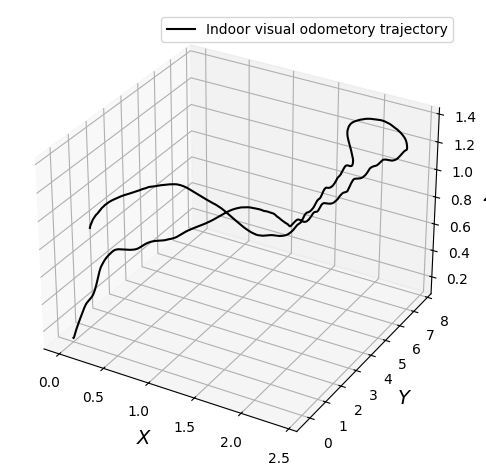

In [5]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
# To visualize in understandable manner, inverse y and z axis
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [6]:
def print_error_report(report, title):
    print(f"----- {title} -----")
    print(f"Mean Absolute Error: {report[ErrorEnum.MAE]}")
    print(f"Root Mean Squared Error: {report[ErrorEnum.RMSE]}")
    print(f"Maximum Error: {report[ErrorEnum.MAX]}")
    print("")

# Apply Kalman Filters using IMU and VO

## EKF

In [9]:
x = np.array([
    [loader.px4_vo_df.iloc[0]['position[0]']],
    [loader.px4_vo_df.iloc[0]['position[1]']],
    [loader.px4_vo_df.iloc[0]['position[2]']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

In [10]:
ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

In [11]:
timestamp = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=timestamp)
original_position = loader.px4_vo_df[loader.vo_pos_columns].iloc[0].values

ekf_mu_x = []
ekf_mu_y = []
ekf_mu_z = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ekf.predict_setup1_2(u=data.values, dt=dt, Q=ekf.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
                
            if data_ref['device'] == 'px4_gps':
                # This will never be called
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][loader.gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ekf.update(z=z, R=ekf.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                x_hat = ekf.x.copy()
                ekf_mu_x.append(x_hat[0, 0])
                ekf_mu_y.append(x_hat[1, 0])
                ekf_mu_z.append(x_hat[2, 0])
                z = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ekf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                ekf.update(z=z, R=R_vo)
                

    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

ekf_mu_x = np.array(ekf_mu_x)
ekf_mu_y = np.array(ekf_mu_y)
ekf_mu_z = np.array(ekf_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 34468/34468 [00:07<00:00, 4803.83it/s]


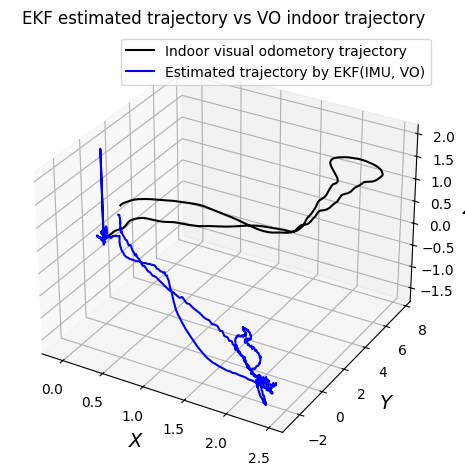

In [12]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EKF estimated trajectory vs VO indoor trajectory")

x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')
ax1.plot(ekf_mu_x, -ekf_mu_y, -ekf_mu_z, label='Estimated trajectory by EKF(IMU, VO)', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [13]:
ekf_imu_vo_error = get_error_report(loader.px4_vo_df[loader.vo_pos_columns].values, 
                            np.array([ekf_mu_x, ekf_mu_y, ekf_mu_z]).T)

print_error_report(
    report=ekf_imu_vo_error,
    title="Deviation between EKF(IMU, VO) estimated pose and VO"
)


----- Deviation between EKF(IMU, VO) estimated pose and VO -----
Mean Absolute Error: 1.456
Root Mean Squared Error: 2.755
Maximum Error: 10.077



## UKF

In [14]:
x = np.array([
    [loader.px4_vo_df.iloc[0]['position[0]']],
    [loader.px4_vo_df.iloc[0]['position[1]']],
    [loader.px4_vo_df.iloc[0]['position[2]']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

alpha_setup = 10.
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

In [15]:
timestamp = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=timestamp)
original_position = loader.px4_vo_df[loader.vo_pos_columns].iloc[0].values

ukf_mu_x = []
ukf_mu_y = []
ukf_mu_z = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ukf.predict_setup1_2(u=data.values, dt=dt, Q=ukf.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            
            if data_ref['device'] == 'px4_gps':
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][loader.gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ukf.update(z=z, R=ukf.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                x_hat = ukf.x.copy()
                ukf_mu_x.append(x_hat[0, 0])
                ukf_mu_y.append(x_hat[1, 0])
                ukf_mu_z.append(x_hat[2, 0])
                
                z = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ukf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                ukf.update(z=z, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

ukf_mu_x = np.array(ukf_mu_x)
ukf_mu_y = np.array(ukf_mu_y)
ukf_mu_z = np.array(ukf_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 34468/34468 [00:14<00:00, 2335.29it/s]


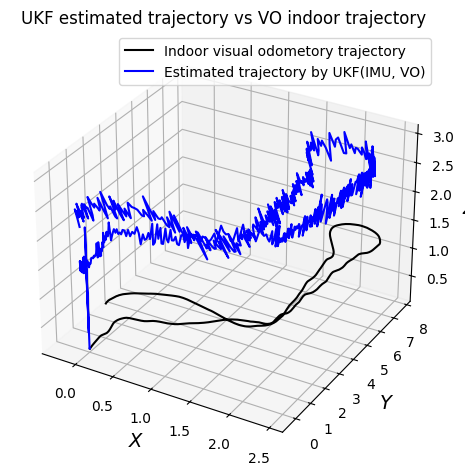

In [16]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("UKF estimated trajectory vs VO indoor trajectory")

x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')
ax1.plot(ukf_mu_x, -ukf_mu_y, -ukf_mu_z, label='Estimated trajectory by UKF(IMU, VO)', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [17]:
ukf_imu_vo_error = get_error_report(loader.px4_vo_df[loader.vo_pos_columns].values, 
                            np.array([ukf_mu_x, ukf_mu_y, ukf_mu_z]).T)

print_error_report(
    report=ukf_imu_vo_error,
    title="Deviation between EKF(IMU, VO) estimated pose and VO"
)


----- Deviation between EKF(IMU, VO) estimated pose and VO -----
Mean Absolute Error: 0.523
Root Mean Squared Error: 0.796
Maximum Error: 2.115



## PF

In [18]:
x = np.array([
    [loader.px4_vo_df.iloc[0]['position[0]']],
    [loader.px4_vo_df.iloc[0]['position[1]']],
    [loader.px4_vo_df.iloc[0]['position[2]']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

importance_resampling = True

pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

In [19]:
timestamp = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=timestamp)
original_position = loader.px4_vo_df[loader.vo_pos_columns].iloc[0].values

pf_mu_x = []
pf_mu_y = []
pf_mu_z = []

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            pf.predict_setup1_2(u=data.values, dt=dt, Q=pf.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][loader.gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                pf.update(z, R=pf.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                x_hat, _ = pf.estimate()
                pf_mu_x.append(x_hat[0])
                pf_mu_y.append(x_hat[1])
                pf_mu_z.append(x_hat[2])
                
                z = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = pf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                pf.update(z, R=R_vo)
                
            if pf._allow_resampling(importance_resampling=importance_resampling):
                pf.resample()

    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

pf_mu_x = np.array(pf_mu_x)
pf_mu_y = np.array(pf_mu_y)
pf_mu_z = np.array(pf_mu_z)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 34468/34468 [09:22<00:00, 61.23it/s]


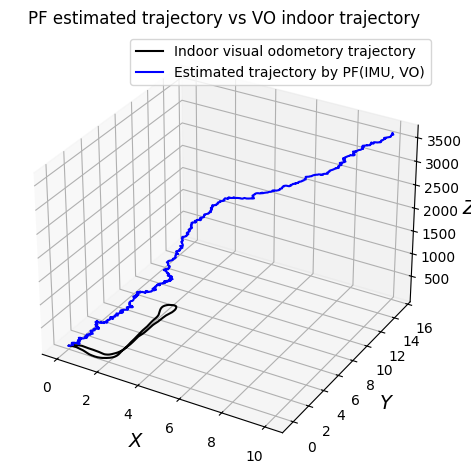

In [20]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("PF estimated trajectory vs VO indoor trajectory")

x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')
ax1.plot(pf_mu_x, -pf_mu_y, -pf_mu_z, label='Estimated trajectory by PF(IMU, VO)', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [21]:
pf_imu_vo_error = get_error_report(loader.px4_vo_df[loader.vo_pos_columns].values, 
                            np.array([pf_mu_x, pf_mu_y, pf_mu_z]).T)
print_error_report(
    report=pf_imu_vo_error,
    title="Deviation between PF(IMU, VO) estimated pose and VO"
)


----- Deviation between PF(IMU, VO) estimated pose and VO -----
Mean Absolute Error: 420.162
Root Mean Squared Error: 961.731
Maximum Error: 3685.01



## EnKF

In [22]:
x = np.array([
    [loader.px4_vo_df.iloc[0]['position[0]']],
    [loader.px4_vo_df.iloc[0]['position[1]']],
    [loader.px4_vo_df.iloc[0]['position[2]']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

n_ensemble = 1024
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)

In [23]:
timestamp = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=timestamp)
original_position = loader.px4_vo_df[loader.vo_pos_columns].iloc[0].values

enkf_mu_x = []
enkf_mu_y = []
enkf_mu_z = []

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    
    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            enkf.predict_setup1_2(u=data.values, dt=dt, Q=enkf.Q)

        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':

                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][loader.gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                enkf.update(z, R=enkf.R_gps)
    
            elif data_ref['device'] == 'px4_vo':
                x_hat = enkf.x.copy().flatten()
                enkf_mu_x.append(x_hat[0])
                enkf_mu_y.append(x_hat[1])
                enkf_mu_z.append(x_hat[2])
                
                z = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = enkf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                enkf.update(z, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

enkf_mu_x = np.array(enkf_mu_x)
enkf_mu_y = np.array(enkf_mu_y)
enkf_mu_z = np.array(enkf_mu_z)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 34468/34468 [04:46<00:00, 120.18it/s]


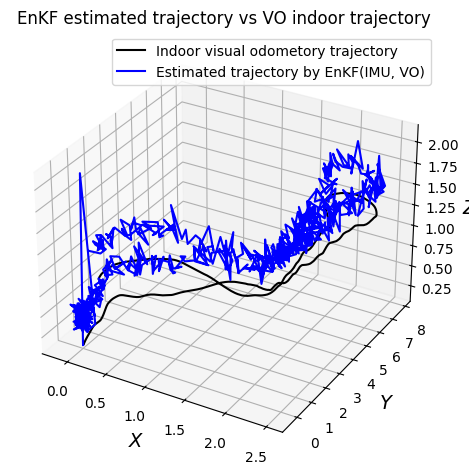

In [24]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EnKF estimated trajectory vs VO indoor trajectory")


x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')
ax1.plot(enkf_mu_x, -enkf_mu_y, -enkf_mu_z, label='Estimated trajectory by EnKF(IMU, VO)', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [25]:
enkf_imu_vo_error = get_error_report(loader.px4_vo_df[loader.vo_pos_columns].values, 
                            np.array([enkf_mu_x, enkf_mu_y, enkf_mu_z]).T)

print_error_report(
    report=enkf_imu_vo_error,
    title="Deviation between EnKF(IMU, VO) estimated pose and VO"
)

----- Deviation between EnKF(IMU, VO) estimated pose and VO -----
Mean Absolute Error: 0.146
Root Mean Squared Error: 0.215
Maximum Error: 2.062



## CKF

In [26]:
x = np.array([
    [loader.px4_vo_df.iloc[0]['position[0]']],
    [loader.px4_vo_df.iloc[0]['position[1]']],
    [loader.px4_vo_df.iloc[0]['position[2]']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

In [27]:
timestamp = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=timestamp)
original_position = loader.px4_vo_df[loader.vo_pos_columns].iloc[0].values

ckf_mu_x = []
ckf_mu_y = []
ckf_mu_z = []

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    
    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ckf.predict_setup1_2(u=data.values, dt=dt, Q=ckf.Q)
    
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                gps_ned = lla_to_ned(
                    sensor["df"].iloc[sensor['index']:sensor['index'] + 1][loader.gps_pose_columns].values.T,
                    original_position
                ).T[0]
                z = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                ckf.update(z, R=ckf.R_gps)
                
            elif data_ref['device'] == 'px4_vo':
                x_hat = ckf.x.copy()
                ckf_mu_x.append(x_hat[0, 0])
                ckf_mu_y.append(x_hat[1, 0])
                ckf_mu_z.append(x_hat[2, 0])
                
                z = sensor["df"].iloc[sensor["index"]][loader.vo_pos_columns].values
                r_vo = sensor["df"].iloc[sensor["index"]][loader.vo_pos_var_columns].values
                if np.isnan(r_vo.sum()):
                    R_vo = ckf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                ckf.update(z, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

ckf_mu_x = np.array(ckf_mu_x)
ckf_mu_y = np.array(ckf_mu_y)
ckf_mu_z = np.array(ckf_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 34468/34468 [00:14<00:00, 2431.97it/s]


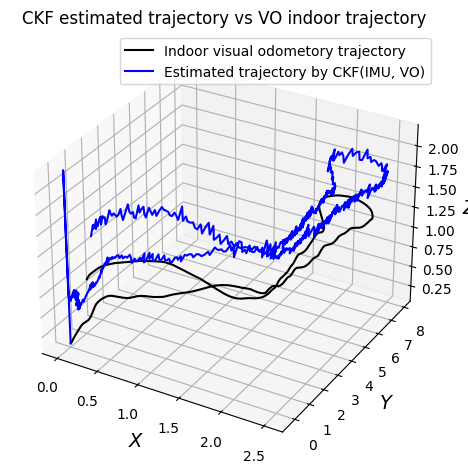

In [28]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("CKF estimated trajectory vs VO indoor trajectory")

x, y, z = loader.px4_vo_df[loader.vo_pos_columns].values.T
ax1.plot(x, -y, -z, label='Indoor visual odometory trajectory', color='black')
ax1.plot(ckf_mu_x, -ckf_mu_y, -ckf_mu_z, label='Estimated trajectory by CKF(IMU, VO)', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

In [29]:
ckf_imu_vo_error = get_error_report(loader.px4_vo_df[loader.vo_pos_columns].values, 
                            np.array([ckf_mu_x, ckf_mu_y, ckf_mu_z]).T)

print_error_report(
    report=ckf_imu_vo_error,
    title="Deviation between CKF(IMU, VO) estimated pose and VO"
)

----- Deviation between CKF(IMU, VO) estimated pose and VO -----
Mean Absolute Error: 0.242
Root Mean Squared Error: 0.31
Maximum Error: 2.115



## Summary

In [30]:
def get_error_df(error_list):
    mae_error = get_error_from_list(error_list, e_type=ErrorEnum.MAE)
    
    rmse_error = get_error_from_list(error_list, e_type=ErrorEnum.RMSE)
    
    max_error = get_error_from_list(error_list, e_type=ErrorEnum.MAX)
    
    errors = np.array([
        mae_error, rmse_error, max_error
    ])
    df = pd.DataFrame(errors, 
                index=["MAE", "RMSE", "MAX"], 
                columns=["EKF", "UKF", "PF", "EnKF", "CKF"])
    return df

In [31]:
imu_vo_error_df = get_error_df(error_list=[
    ekf_imu_vo_error, 
    ukf_imu_vo_error, 
    pf_imu_vo_error, 
    enkf_imu_vo_error, 
    ckf_imu_vo_error
])

In [32]:
imu_vo_error_df

,EKF,UKF,PF,EnKF,CKF
MAE,1.456,0.523,420.162,0.146,0.242
RMSE,2.755,0.796,961.731,0.215,0.310
MAX,10.077,2.115,3685.010,2.062,2.115


# Conclusion

In this notebook, five type of kalman filters are applied to the PX4 drone dataset collected indoor environment. The dataset includes IMU and Visual Odometry data those are exported in voxl and px4 respectively. 

The filter result shows that EnKF provides the best performance among the other filter in all metric and CKF follows the EnKF. 

However, the estimated trajectory that EnKF provides oscillates back and forth, which may result in estimation error in the other trajectory. The CKF, on the other hand, has less oscillations and has a potential to reduce error when adding bias term in z-axis of the trajectory.